# Cluster trends and model comparisons

This notebook uses the cluster determined in the previous notebook to make simple forecast on the `total_count`. Different models are used to forecast and compared.

The structure of the notebook is as follows:
- Create forecasting feature table and split research panel into test and training sets.
- Evaluate different models and compare their MAE and RMSE at the site level.
- Observe cluster level trends and predictions.
- Observe best performing model predictions.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import duckdb

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso, HuberRegressor

import matplotlib as mpl
import matplotlib.pyplot as plt
# from matplotlib.ticker import AutoMinorLocator
import seaborn as sns

## Create forecast feature table and make testing and training splits

In [2]:
# connect to local db
con = duckdb.connect("../data/transport_project.duckdb")
con.execute("SELECT * FROM research_panel LIMIT 5").fetch_df()

,site_id,survey_date,year,month,total_count,time_0600,time_0700,time_0800,time_1600,time_1700,time_1800,longitude,latitude,cluster
0,2,2010-03-01,2010,March,140,7,12,22,29,32,38,151.208601,-33.878286,0
1,2,2010-10-01,2010,October,84,5,16,23,12,13,15,151.208601,-33.878286,0
2,2,2011-03-01,2011,March,106,19,22,12,20,22,11,151.208601,-33.878286,0
3,2,2011-10-01,2011,October,243,40,45,39,32,53,34,151.208601,-33.878286,0
4,2,2012-03-01,2012,March,299,12,23,28,48,112,76,151.208601,-33.878286,0


In [3]:
# make forecast features using lag-1, lag-2, and cluster
con.execute("""
    CREATE OR REPLACE TABLE clustered_sites_with_count_lags AS
    SELECT
        site_id, cluster,
        survey_date, year, month,
        total_count,
        LAG(total_count, 1, NULL) OVER(
            PARTITION BY site_id
            ORDER BY survey_date
        ) AS lag_1_total,
        LAG(total_count, 2, NULL) OVER(
            PARTITION BY site_id
            ORDER BY survey_date
        ) AS lag_2_total,
    FROM research_panel
    ORDER BY cluster, site_id, survey_date
""")

df_lags = con.execute("SELECT * FROM clustered_sites_with_count_lags").fetch_df()
df_lags.head()

,site_id,cluster,survey_date,year,month,total_count,lag_1_total,lag_2_total
0,2,0,2010-03-01,2010,March,140,<NA>,<NA>
1,2,0,2010-10-01,2010,October,84,140,<NA>
2,2,0,2011-03-01,2011,March,106,84,140
3,2,0,2011-10-01,2011,October,243,106,84
4,2,0,2012-03-01,2012,March,299,243,106


In [4]:
# remove NaNs
df_base = df_lags.dropna(subset=["lag_1_total", "lag_2_total"]).copy()

# split test/train
train = df_base[df_base["year"] <= 2022].copy()
test  = df_base[df_base["year"] >= 2023].copy()

# add seasonal feature
train["is_october"] = (train["month"] == 'October').astype(int)
test["is_october"]  = (test["month"] == 'October').astype(int)

X_train = train[["lag_1_total", "lag_2_total", "cluster", "is_october"]].copy()
X_test  = test[["lag_1_total", "lag_2_total", "cluster", "is_october"]].copy()

# since cluster is nominally categorical, need betas for each cluster
# y = β0 cluster_0 + β1 cluster_1 + β2 cluster_2
X_train = pd.get_dummies(X_train, columns=["cluster"], drop_first=True)
X_test  = pd.get_dummies(X_test, columns=["cluster"], drop_first=True)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

## Evaluate and compare different models

In [5]:
# helper to pprint out model stats
def evaluate_model_row(name, y_true, y_pred, note=None):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "Notes": note,
    }

In [6]:
y_train = train["total_count"]
y_test  = test["total_count"]

results = []

# baseline models
y_pred_lag1 = test["lag_1_total"]
y_pred_lag2 = test["lag_2_total"]

# linear models
linear = LinearRegression()
lasso = Lasso(alpha=1.0, max_iter=10000, random_state=42)
huber = HuberRegressor(epsilon=1.35, alpha=0.0001, max_iter=1000)

linear.fit(X_train, y_train)
lasso.fit(X_train, y_train)
huber.fit(X_train, y_train)

y_pred_linear = linear.predict(X_test)
y_pred_lasso = lasso.predict(X_test)
y_pred_huber = huber.predict(X_test)

# clean table rows
results.append(evaluate_model_row("Lag-1 baseline", y_test, y_pred_lag1, "Persistence baseline"))
results.append(evaluate_model_row("Lag-2 baseline", y_test, y_pred_lag2, "Same-season baseline"))
results.append(evaluate_model_row("Linear", y_test, y_pred_linear, "Lag + cluster features"))
results.append(evaluate_model_row("Lasso", y_test, y_pred_lasso, "Regularised linear model"))
results.append(evaluate_model_row("Huber", y_test, y_pred_huber, "Robust to large residuals"))

model_table = pd.DataFrame(results)

baseline = model_table.loc[model_table["Model"] == "Lag-1 baseline"].iloc[0]

# compare with baseline
model_table["ΔMAE vs Lag-1"] = (
    100 * (model_table["MAE"] - baseline["MAE"]) / baseline["MAE"]
)
model_table["ΔRMSE vs Lag-1"] = (
    100 * (model_table["RMSE"] - baseline["RMSE"]) / baseline["RMSE"]
)
model_table = model_table[
    ["Model", "MAE", "RMSE", "ΔMAE vs Lag-1", "ΔRMSE vs Lag-1", "Notes"]
]

model_table = model_table.sort_values("RMSE").reset_index(drop=True)
model_table

,Model,MAE,RMSE,ΔMAE vs Lag-1,ΔRMSE vs Lag-1,Notes
0,Huber,111.925067,209.795877,-5.854793,-5.270246,Robust to large residuals
1,Lasso,114.139802,210.981575,-3.991881,-4.734865,Regularised linear model
2,Linear,115.166746,211.374279,-3.128072,-4.557546,Lag + cluster features
3,Lag-1 baseline,118.885572,221.467774,0.000000,0.000000,Persistence baseline
4,Lag-2 baseline,135.927861,249.106358,14.335035,12.479731,Same-season baseline


In [7]:
# readme_table = model_table.copy()

# readme_table["MAE"] = readme_table["MAE"].map(lambda x: f"{x:.2f}")
# readme_table["RMSE"] = readme_table["RMSE"].map(lambda x: f"{x:.2f}")
# readme_table["ΔMAE vs Lag-1"] = readme_table["ΔMAE vs Lag-1"].map(lambda x: f"{x:.1f}%")
# readme_table["ΔRMSE vs Lag-1"] = readme_table["ΔRMSE vs Lag-1"].map(lambda x: f"{x:.1f}%")

# print(readme_table.to_markdown(index=False))

## Cluster level trends and predictions

In [8]:
# compare Huber with baseline lag-1
test_eval = test.copy()
test_eval["y_true"] = y_test.values
test_eval["huber_pred"] = y_pred_huber

rows = []
for c in sorted(test_eval["cluster"].unique()):
    d = test_eval[test_eval["cluster"] == c].copy()

    mae_lag1   = mean_absolute_error(d["y_true"], d["lag_1_total"])
    mae_huber  = mean_absolute_error(d["y_true"], d["huber_pred"])
    rmse_lag1  = np.sqrt(mean_squared_error(d["y_true"], d["lag_1_total"]))
    rmse_huber = np.sqrt(mean_squared_error(d["y_true"], d["huber_pred"]))

    rows.append({
        "Cluster": c, "Observations": len(d),
        "MAE Lag-1": mae_lag1, "MAE Huber": mae_huber,
        "RMSE Lag-1": rmse_lag1, "RMSE Huber": rmse_huber,
        "MAE improvement": mae_lag1 - mae_huber, "RMSE improvement": rmse_lag1 - rmse_huber
    })

compare_by_cluster = pd.DataFrame(rows)
compare_by_cluster

,Cluster,Observations,MAE Lag-1,MAE Huber,RMSE Lag-1,RMSE Huber,MAE improvement,RMSE improvement
0,0,216,80.912037,74.788329,113.242672,106.365538,6.123708,6.877134
1,1,108,68.935185,66.919399,111.232031,109.345123,2.015786,1.886909
2,2,78,293.205128,277.080807,447.372471,423.034257,16.124321,24.338215


In [9]:
# print(
#     compare_by_cluster
#     .round({"MAE Lag-1": 3, "MAE Huber": 3, "RMSE Lag-1": 3, "RMSE Huber": 3, "MAE improvement": 3, "RMSE improvement": 3})
#     .to_markdown(index=False)
# )

In [10]:
# relative cluster accuracy
def cluster_relative_accuracy_table(
    df,
    actual_col="y_true",
    pred_col="huber_pred",
    cluster_col="cluster",
):
    out = []

    for cluster, g in df.groupby(cluster_col):
        y = g[actual_col].to_numpy()
        yhat = g[pred_col].to_numpy()

        error = yhat - y

        # Percentage error per observation
        ape = np.abs(error / y)
        rmse = np.sqrt(np.mean(error**2))

        mean_actual = y.mean()
        rel_rmse = rmse / mean_actual

        out.append({
            "Cluster": cluster,
            "Observations": len(g),
            "Median APE": np.median(ape),
            "Relative RMSE": rel_rmse,
        })

    table = pd.DataFrame(out).sort_values("Relative RMSE").reset_index(drop=True)

    return table

cluster_relative_accuracy_table(test_eval)
# print(cluster_relative_accuracy_table(test_eval).round(3).to_markdown(index=False))

,Cluster,Observations,Median APE,Relative RMSE
0,0,216,0.122234,0.190954
1,1,108,0.094910,0.227254
2,2,78,0.115196,0.252272


In [11]:
# compute cluster trends over the whole period
cluster_trends_balanced = con.execute("""
    SELECT
        cluster,
        survey_date,
        COUNT(*) AS n_sites,
        AVG(total_count) AS mean_total_count,
        MEDIAN(total_count) AS median_total_count,
        SUM(total_count) AS sum_total_count
    FROM research_panel
    GROUP BY cluster, survey_date
    ORDER BY cluster, survey_date
""").fetch_df()

cluster_trends_balanced

,cluster,survey_date,n_sites,mean_total_count,median_total_count,sum_total_count
0,0,2010-03-01,36,195.333333,142.0,7032.0
1,0,2010-10-01,36,241.972222,192.0,8711.0
2,0,2011-03-01,36,253.916667,193.0,9141.0
3,0,2011-10-01,36,294.861111,216.5,10615.0
4,0,2012-03-01,36,325.083333,293.5,11703.0
...,...,...,...,...,...,...
88,2,2023-10-01,13,1663.769231,1642.0,21629.0
89,2,2024-03-01,13,1695.538462,1463.0,22042.0
90,2,2024-10-01,13,1624.923077,1581.0,21124.0
91,2,2025-03-01,13,1913.307692,1686.0,24873.0


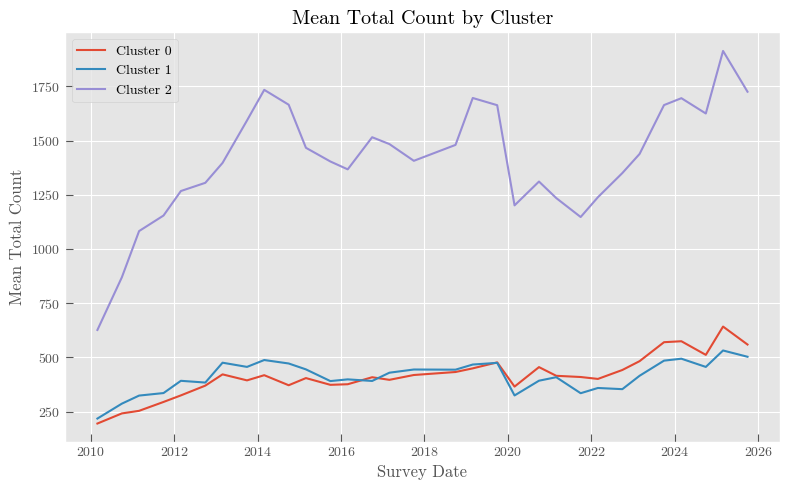

In [ ]:
# plot the trend 
plt.style.use("ggplot")

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["cmr10"],
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True,
    "axes.unicode_minus": False,
})

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(3):
    sns.lineplot(
        data=cluster_trends_balanced[cluster_trends_balanced["cluster"] == i],
        x="survey_date",
        y="mean_total_count",
        ax=ax,
        label=f"Cluster {i}",
    )

ax.set_title("Mean Total Count by Cluster")
ax.set_xlabel("Survey Date")
ax.set_ylabel("Mean Total Count")

ax.tick_params(axis="both", which="major", direction="in", length=6)
ax.tick_params(axis="both", which="minor", direction="in", length=3)

plt.tight_layout()
# plt.savefig("../outputs/cluster_trends.png", format="png")
plt.show()

## Predictions vs. Acutal value

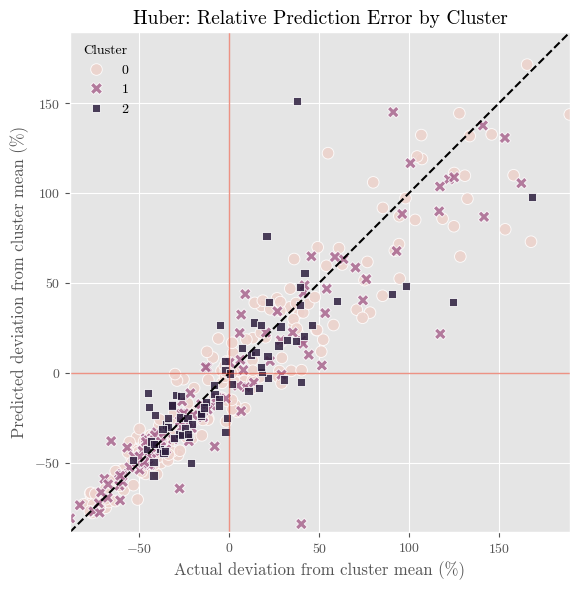

In [ ]:
# scatter plot for predicted vs actual values
plot_df = test_eval.copy()

# Mean actual count within each cluster
cluster_means = plot_df.groupby("cluster")["y_true"].transform("mean")

plot_df["y_true_pct_dev"] = 100 * (plot_df["y_true"] / cluster_means - 1)
plot_df["huber_pred_pct_dev"] = 100 * (plot_df["huber_pred"] / cluster_means - 1)

fig, ax = plt.subplots(figsize=(7, 6))

sns.scatterplot(
    data=plot_df,
    x="y_true_pct_dev",
    y="huber_pred_pct_dev",
    hue="cluster",
    style="cluster",
    s=70,
    alpha=0.85,
    ax=ax,
)

xy_min = min(plot_df["y_true_pct_dev"].min(), plot_df["huber_pred_pct_dev"].min())
xy_max = max(plot_df["y_true_pct_dev"].max(), plot_df["huber_pred_pct_dev"].max())

ax.plot([xy_min, xy_max], [xy_min, xy_max], "--", linewidth=1.5, color="black")

ax.axhline(0, linewidth=1, alpha=0.6)
ax.axvline(0, linewidth=1, alpha=0.6)

ax.set_xlim(xy_min, xy_max)
ax.set_ylim(xy_min, xy_max)
ax.set_aspect("equal", adjustable="box")

ax.set_title("Huber: Relative Prediction Error by Cluster", fontsize=14)
ax.set_xlabel("Actual deviation from cluster mean (%)", fontsize=12)
ax.set_ylabel("Predicted deviation from cluster mean (%)", fontsize=12)

ax.legend(title="Cluster", frameon=False)

plt.tight_layout()
# plt.savefig("../outputs/predicted_vs_actual.png", format="png")
plt.show()